# HyperRAG V2 — Notebook 4: HyperRAG + Final Comparison

**Goal:** Build HyperRAG, understand how the hyperlink graph improves multi-hop retrieval, and produce a final 3-system comparison chart.

**HyperRAG adds one extra step on top of Simple RAG:**

```
Simple RAG:  query → FAISS → top-k pages
HyperRAG  :  query → FAISS → top-k pages → 1-hop graph expansion → re-rank → top-k + expand_k pages
```

**Why does this help for multi-hop questions?**  
A question like *"What is the birthplace of the director of Inception?"* needs:
1. Page about *Inception* (to find director = Christopher Nolan)
2. Page about *Christopher Nolan* (to find birthplace = London)

FAISS might find the Inception page but miss Nolan's page. The hyperlink graph then expands to Nolan's page because Inception's article links to it.

**Prerequisite:** Run notebooks 01, 02, and 03 first.


In [1]:
import json
import html as html_lib
from pathlib import Path
from collections import Counter

import faiss
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from bs4 import BeautifulSoup
from sentence_transformers import SentenceTransformer

# ── Paths ─────────────────────────────────────────────────────────────────────
if Path('utils.py').exists():
    BASE_DIR = Path('.')
elif Path('v2/utils.py').exists():
    BASE_DIR = Path('v2')
else:
    raise FileNotFoundError('Run from v2/ or from HyperRAG-M2/')

DATA_DIR = BASE_DIR / 'data'

with open(DATA_DIR / 'corpus_001.json')    as f: corpus    = json.load(f)
with open(DATA_DIR / 'questions_001.json') as f: questions = json.load(f)

print(f'Corpus    : {len(corpus)} pages')
print(f'Questions : {len(questions)} questions')


W0427 23:19:44.611000 94160 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Corpus    : 9999 pages
Questions : 5329 questions


---
## Step 1 — Extract Hyperlinks from Wikipedia HTML

Each Wikipedia page contains links to other Wikipedia articles. We extract these from the HTML `<a href>` tags. These links form the edges of the hyperlink graph.


In [2]:
def extract_links(html: str) -> list[str]:
    """
    Extract Wikipedia article titles from HTML <a href> links.
    Only keeps links that start with /wiki/ and have no colon in the title
    (colons indicate non-article pages like Category:, File:, Talk:, etc.).
    Returns deduplicated list of article titles.
    """
    soup  = BeautifulSoup(html, 'html.parser')
    seen  = set()
    titles = []
    for a in soup.find_all('a', href=True):
        href = a['href']
        if href.startswith('/wiki/') and ':' not in href[6:]:
            title = href[6:].replace('_', ' ')
            title = html_lib.unescape(title)
            if title and title not in seen:
                seen.add(title)
                titles.append(title)
    return titles


print('extract_links() defined.')


extract_links() defined.


In [3]:
# ── Test: extract links from the first corpus page ────────────────────────────
page  = corpus[0]
links = extract_links(page['html'])

print(f'Page  : {page["title"]}')
print(f'Links found in HTML: {len(links)}')
print()
print('First 15 links:')
for i, l in enumerate(links[:15], 1):
    print(f'  {i:2d}. {l}')
print()
print('Note: These are OTHER Wikipedia articles this page links to.')


Page  : The Oberoi Group
Links found in HTML: 377

First 15 links:
   1. Private company
   2. Hospitality industry
   3. Mohan Singh Oberoi
   4. New Delhi
   5. India
   6. Hotel
   7. Resort
   8. Luxury hotel
   9. River cruise
  10. Asia
  11. Rai Bahadur
  12. Delhi
  13. Shimla
  14. Prithvi Raj Singh Oberoi
  15. Trident Hotel, Nariman Point

Note: These are OTHER Wikipedia articles this page links to.


In [4]:
# Compare links from HTML extraction vs links stored in corpus["links"]
# (corpus["links"] was fetched via the Wikipedia API in notebook 01)
api_links  = set(page['links'])
html_links = set(links)

print(f'Links from Wikipedia API  : {len(api_links)}')
print(f'Links extracted from HTML : {len(html_links)}')
print(f'Overlap                   : {len(api_links & html_links)}')
print(f'Only in API               : {len(api_links - html_links)}')
print(f'Only in HTML              : {len(html_links - api_links)}')
print()
print('We will use corpus["links"] (API links) for the graph — they are cleaner.')


Links from Wikipedia API  : 372
Links extracted from HTML : 377
Overlap                   : 320
Only in API               : 52
Only in HTML              : 57

We will use corpus["links"] (API links) for the graph — they are cleaner.


---
## Step 2 — Build the Hyperlink Graph

We build a **directed graph** where:
- Each node is a Wikipedia page title
- Each directed edge (A → B) means page A contains a link to page B

We only keep nodes that are in our corpus — this keeps the graph small and focused.


In [5]:
def build_graph(corpus: list[dict]) -> nx.DiGraph:
    """
    Build a directed hyperlink graph from corpus pages.
    Nodes = page titles that are in the corpus.
    Edges = hyperlinks between corpus pages.
    Only edges where both source AND target are in the corpus are added.
    """
    corpus_titles = {p['title'] for p in corpus}
    G = nx.DiGraph()
    G.add_nodes_from(corpus_titles)   # add all corpus pages as nodes

    edge_count = 0
    for page in corpus:
        src = page['title']
        for link in page['links']:
            if link in corpus_titles and link != src:
                G.add_edge(src, link)
                edge_count += 1

    return G


print('build_graph() defined.')


build_graph() defined.


In [6]:
graph = build_graph(corpus)

print('Graph Statistics')
print('=' * 40)
print(f'Nodes (pages)    : {graph.number_of_nodes()}')
print(f'Edges (hyperlinks): {graph.number_of_edges()}')
print(f'Density           : {nx.density(graph):.4f}')
print()
print('Out-degree (how many corpus pages this page links to):')
for node, deg in sorted(graph.out_degree(), key=lambda x: -x[1]):
    print(f'  {node[:45]:<45} → {deg} links')
print()
print('In-degree (how many corpus pages link TO this page):')
for node, deg in sorted(graph.in_degree(), key=lambda x: -x[1]):
    print(f'  {node[:45]:<45} ← {deg} links')


Graph Statistics
Nodes (pages)    : 9999
Edges (hyperlinks): 86244
Density           : 0.0009

Out-degree (how many corpus pages this page links to):
  Barbra Streisand                              → 171 links
  Cher                                          → 141 links
  Taylor Swift                                  → 135 links
  Elton John                                    → 133 links
  Dustin Hoffman                                → 133 links
  Steven Spielberg                              → 129 links
  Judi Dench                                    → 127 links
  Frank Sinatra                                 → 126 links
  Clint Eastwood                                → 123 links
  Mel Brooks                                    → 121 links
  Julie Andrews                                 → 120 links
  Paul Newman                                   → 119 links
  Bill Murray                                   → 111 links
  Jack Nicholson                                → 110 links
  Eminem  

---
## Step 3 — Visualize the Hyperlink Graph


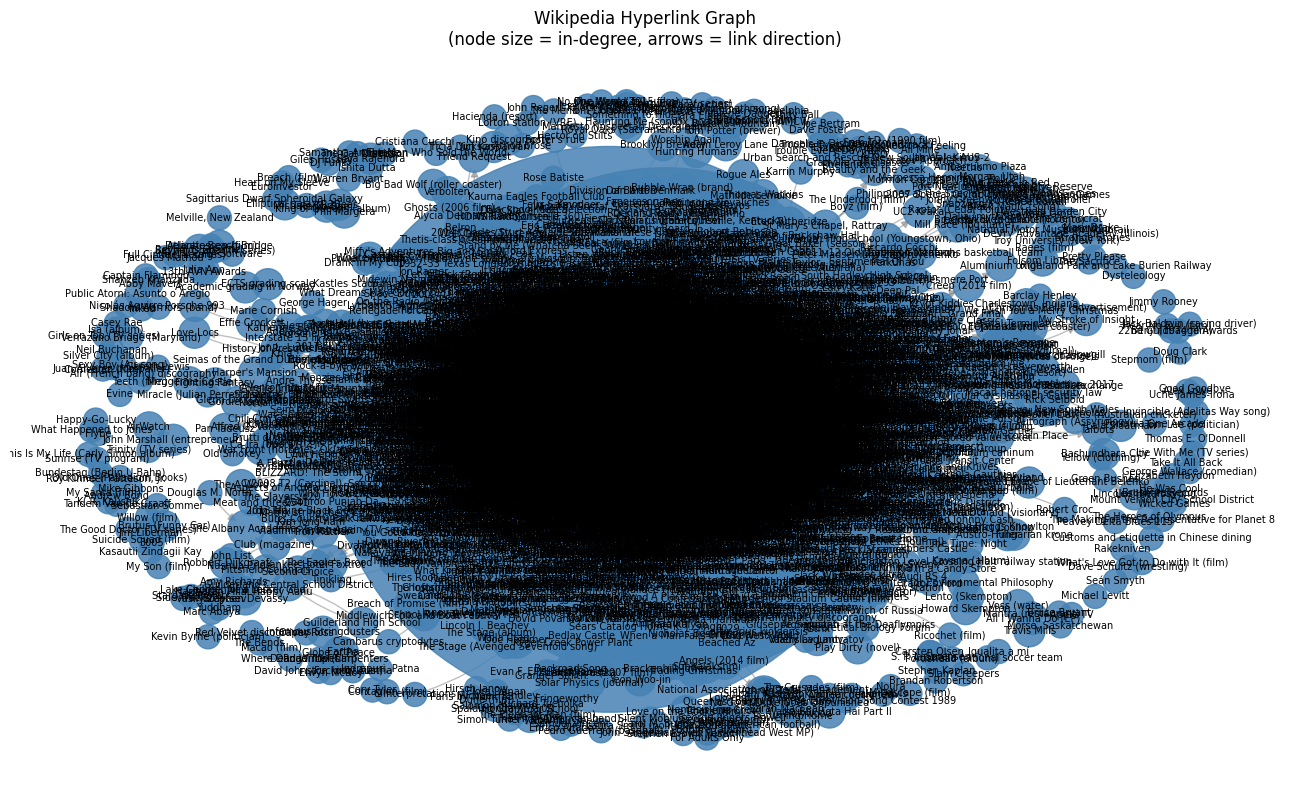

Saved: data/hyperlink_graph.png


In [7]:
# Only visualize if there are edges to show
if graph.number_of_edges() == 0:
    print('No edges in graph — all corpus pages are isolated nodes.')
    print('This can happen with a small corpus where pages do not link to each other.')
else:
    fig, ax = plt.subplots(figsize=(13, 8))

    # Layout
    pos = nx.spring_layout(graph, seed=42, k=2.5)

    # Node sizes proportional to in-degree (hub pages are larger)
    in_degrees   = dict(graph.in_degree())
    node_sizes   = [300 + in_degrees[n] * 200 for n in graph.nodes()]

    # Draw
    nx.draw_networkx_nodes(graph, pos, node_size=node_sizes,
                           node_color='steelblue', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=7, ax=ax)
    nx.draw_networkx_edges(graph, pos, arrows=True, arrowsize=12,
                           edge_color='gray', alpha=0.5,
                           connectionstyle='arc3,rad=0.1', ax=ax)

    ax.set_title('Wikipedia Hyperlink Graph\n(node size = in-degree, arrows = link direction)',
                 fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(str(DATA_DIR / 'hyperlink_graph.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved: data/hyperlink_graph.png')


---
## Step 4 — 1-Hop Graph Expansion

After FAISS retrieves the initial top-k pages, we **expand** the result set by walking one hop in the graph:

1. For each retrieved page, collect all pages it **links to** (successors) and **pages that link to it** (predecessors)
2. Keep only pages that are in the corpus and NOT already retrieved
3. Re-rank the candidates by query similarity (FAISS again, on this small set)
4. Take the top `expand_k` new pages

> We expand in BOTH directions (out-edges and in-edges) to capture co-reference relationships.


In [8]:
# We need embed/retrieve for HyperRAG — define them here (same as notebooks 02 & 03)
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
_model = None

def get_model():
    global _model
    if _model is None:
        print(f'Loading {MODEL_NAME} ...')
        _model = SentenceTransformer(MODEL_NAME)
        print('Model ready.')
    return _model

def embed_texts(texts):
    model = get_model()
    vecs  = model.encode(texts, show_progress_bar=len(texts) > 20, convert_to_numpy=True)
    vecs  = vecs.astype('float32')
    faiss.normalize_L2(vecs)
    return vecs

def build_index(corpus):
    print(f'Building index for {len(corpus)} pages ...')
    vecs = embed_texts([p['text'] for p in corpus])
    idx  = faiss.IndexFlatIP(vecs.shape[1])
    idx.add(vecs)
    print(f'Index ready: {idx.ntotal} vectors')
    return idx

def retrieve(query, index, corpus, k=5):
    q_vec = embed_texts([query])
    scores, indices = index.search(q_vec, k)
    results = []
    for i, s in zip(indices[0], scores[0]):
        if 0 <= i < len(corpus):
            p = dict(corpus[i])
            p['_score'] = float(s)
            results.append(p)
    return results

index = build_index(corpus)
print('Embedding functions and FAISS index ready.')


Building index for 9999 pages ...
Loading sentence-transformers/all-MiniLM-L6-v2 ...
Model ready.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Index ready: 9999 vectors
Embedding functions and FAISS index ready.


In [9]:
def expand_neighbors(
    query:         str,
    initial_pages: list[dict],
    corpus:        list[dict],
    graph:         nx.DiGraph,
    expand_k:      int = 3,
) -> list[dict]:
    """
    1-hop graph expansion.
    Given the initial retrieved pages, find their neighbors in the graph,
    re-rank by query similarity, and return the top expand_k new pages.
    Returns only the NEW pages (not the initial ones).
    """
    title_to_page   = {p['title']: p for p in corpus}
    initial_titles  = {p['title'] for p in initial_pages}
    neighbor_titles = set()

    for page in initial_pages:
        if not graph.has_node(page['title']):
            continue
        # Out-edges: pages this page links TO
        for nbr in graph.successors(page['title']):
            if nbr in title_to_page and nbr not in initial_titles:
                neighbor_titles.add(nbr)
        # In-edges: pages that link TO this page
        for nbr in graph.predecessors(page['title']):
            if nbr in title_to_page and nbr not in initial_titles:
                neighbor_titles.add(nbr)

    if not neighbor_titles or expand_k <= 0:
        return []

    # Re-rank neighbor candidates by query similarity
    neighbor_pages = [title_to_page[t] for t in neighbor_titles]
    n_embed = embed_texts([p['text'] for p in neighbor_pages])
    q_embed = embed_texts([query])
    scores  = (q_embed @ n_embed.T)[0]             # dot product = cosine sim
    top_idx = scores.argsort()[::-1][:expand_k]    # top expand_k by score
    return [neighbor_pages[i] for i in top_idx]


print('expand_neighbors() defined.')


expand_neighbors() defined.


In [10]:
# ── Test: see what graph expansion adds for a sample question ─────────────────
q = questions[0]
print(f'Question          : {q["question"]}')
print(f'Gold answer       : {q["answer"]}')
print(f'Supporting pages  : {q["supporting_titles"]}')
print()

initial_pages = retrieve(q['question'], index, corpus, k=5)
neighbors     = expand_neighbors(q['question'], initial_pages, corpus, graph, expand_k=3)

print('FAISS initial retrieval (k=5):')
for p in initial_pages:
    gold = '✓' if p['title'] in q['supporting_titles'] else ' '
    print(f'  {gold} {p["title"][:50]}  (score={p["_score"]:.3f})')
print()
print(f'Graph expansion added {len(neighbors)} new page(s):')
for p in neighbors:
    gold = '✓' if p['title'] in q['supporting_titles'] else ' '
    print(f'  {gold} {p["title"][:50]}')


Question          : The Oberoi family is part of a hotel company that has a head office in what city?
Gold answer       : Delhi
Supporting pages  : ['The Oberoi Group', 'Oberoi family']

FAISS initial retrieval (k=5):
  ✓ Oberoi family  (score=0.651)
  ✓ The Oberoi Group  (score=0.651)
    Allard Roen  (score=0.396)
    InterContinental Hotels Group  (score=0.364)
    Luxottica  (score=0.358)

Graph expansion added 3 new page(s):
    Holiday Inn
    Fossil Group
    Diageo


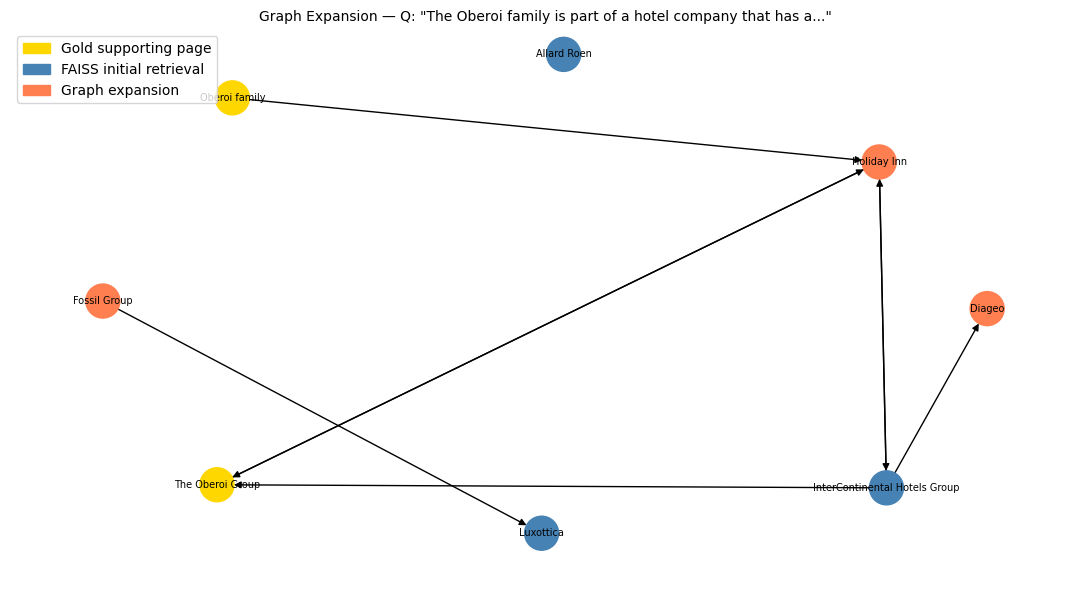

In [11]:
# Visualize the expansion for question 0 (if graph has edges)
if graph.number_of_edges() > 0:
    initial_titles  = [p['title'] for p in initial_pages]
    neighbor_titles = [p['title'] for p in neighbors]
    gold_titles     = set(q['supporting_titles'])

    # Build a small subgraph of relevant nodes
    relevant = set(initial_titles) | set(neighbor_titles) | gold_titles
    subgraph  = graph.subgraph(relevant).copy()
    # Add isolated nodes that aren't connected
    for t in relevant:
        if t not in subgraph:
            subgraph.add_node(t)

    fig, ax = plt.subplots(figsize=(11, 6))
    pos = nx.spring_layout(subgraph, seed=42, k=3)

    def node_color(n):
        if n in gold_titles:      return 'gold'
        if n in initial_titles:   return 'steelblue'
        if n in neighbor_titles:  return 'coral'
        return 'lightgray'

    colors = [node_color(n) for n in subgraph.nodes()]
    nx.draw_networkx(subgraph, pos, node_color=colors, node_size=600,
                     font_size=7, arrows=True, ax=ax)

    gold_p  = mpatches.Patch(color='gold',      label='Gold supporting page')
    init_p  = mpatches.Patch(color='steelblue', label='FAISS initial retrieval')
    exp_p   = mpatches.Patch(color='coral',     label='Graph expansion')
    ax.legend(handles=[gold_p, init_p, exp_p], loc='upper left')
    ax.set_title(f'Graph Expansion — Q: "{q["question"][:55]}..."', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(str(DATA_DIR / 'expansion_viz.png'), dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('No graph edges to visualize.')
    print('HyperRAG will fall back to the FAISS initial retrieval.')


---
## Step 5 — Full HyperRAG Pipeline


In [12]:
def hyperrag(
    question:  str,
    index:     faiss.IndexFlatIP,
    corpus:    list[dict],
    graph:     nx.DiGraph,
    k:         int = 5,
    expand_k:  int = 3,
) -> tuple[str, list[str]]:
    """
    HyperRAG: dense retrieval + 1-hop graph expansion.

    Returns:
      context        (str)  — plain text of initial + expanded pages
      all_titles     (list) — titles of all pages in context

    Algorithm:
      1. FAISS: retrieve top-k pages
      2. Graph: expand with 1-hop neighbors (re-ranked, top expand_k)
      3. Context = initial pages + expanded pages (plain text)
    """
    initial_pages  = retrieve(question, index, corpus, k=k)
    expanded_pages = expand_neighbors(question, initial_pages, corpus, graph, expand_k=expand_k)
    all_pages      = initial_pages + expanded_pages
    context        = '\n\n'.join(p['text'] for p in all_pages)
    all_titles     = [p['title'] for p in all_pages]
    return context, all_titles


print('hyperrag() defined.')


hyperrag() defined.


In [13]:
# ── Test HyperRAG on question 0 ───────────────────────────────────────────────
q         = questions[0]
ctx, ttls = hyperrag(q['question'], index, corpus, graph, k=5, expand_k=3)

print(f'Question          : {q["question"]}')
print(f'Gold answer       : {q["answer"]}')
print(f'Supporting pages  : {q["supporting_titles"]}')
print(f'Retrieved titles  : {ttls}')
print(f'Context length    : {len(ctx)} chars')


Question          : The Oberoi family is part of a hotel company that has a head office in what city?
Gold answer       : Delhi
Supporting pages  : ['The Oberoi Group', 'Oberoi family']
Retrieved titles  : ['Oberoi family', 'The Oberoi Group', 'Allard Roen', 'InterContinental Hotels Group', 'Luxottica', 'Holiday Inn', 'Fossil Group', 'Diageo']
Context length    : 93740 chars


---
## Step 6 — Evaluate HyperRAG on All 20 Questions


In [14]:
def compute_em(context, gold_answer):
    return 1.0 if gold_answer.lower() in context.lower() else 0.0

def compute_f1(context, gold_answer):
    pred = context.lower().split()
    gold = gold_answer.lower().split()
    if not pred or not gold:
        return 0.0
    pc = Counter(pred)
    gc = Counter(gold)
    overlap = sum((pc & gc).values())
    p = overlap / len(pred)
    r = overlap / len(gold)
    return 0.0 if p + r == 0 else 2*p*r/(p+r)

def compute_sr(retrieved_titles, gold_titles):
    if not gold_titles:
        return 0.0
    return sum(1 for t in gold_titles if t in set(retrieved_titles)) / len(gold_titles)

print('Metric functions defined.')


Metric functions defined.


In [15]:
K = 5
EXPAND_K = 3

results_hyper = []
for q in questions:
    ctx, ttls = hyperrag(q['question'], index, corpus, graph, k=K, expand_k=EXPAND_K)
    results_hyper.append({
        'id':               q['id'],
        'question':         q['question'],
        'answer':           q['answer'],
        'em':               compute_em(ctx, q['answer']),
        'f1':               compute_f1(ctx, q['answer']),
        'supporting_recall': compute_sr(ttls, q['supporting_titles']),
    })

mean_em_hyper  = sum(r['em']  for r in results_hyper) / len(results_hyper)
mean_f1_hyper  = sum(r['f1']  for r in results_hyper) / len(results_hyper)
mean_spr_hyper = sum(r['supporting_recall'] for r in results_hyper) / len(results_hyper)

print('HyperRAG Results (k=5, expand_k=3)')
print('=' * 50)
print(f'Mean EM               : {mean_em_hyper:.3f}')
print(f'Mean F1               : {mean_f1_hyper:.3f}')
print(f'Mean Supporting Recall: {mean_spr_hyper:.3f}')


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

HyperRAG Results (k=5, expand_k=3)
Mean EM               : 0.756
Mean F1               : 0.000
Mean Supporting Recall: 0.760


---
## Step 7 — Final 3-System Comparison

This is the main result of the V2 project: **Simple RAG vs HtmlRAG vs HyperRAG**.


In [17]:
with open(DATA_DIR / 'results_simple_rag.json') as f:
    simple_data = json.load(f)
with open(DATA_DIR / 'results_htmlrag.json') as f:
    html_data = json.load(f)

print('Loaded results from notebooks 02 and 03.')
print()
print('Summary:')
print(f'{"System":<15} {"EM":>6} {"F1":>6} {"Supp. Recall":>14}')
print('-' * 45)
print(f'{"Simple RAG":<15} {simple_data["mean_em"]:>6.3f} {simple_data["mean_f1"]:>6.3f} {simple_data["mean_sr"]:>14.3f}')
print(f'{"HtmlRAG":<15} {html_data["mean_em"]:>6.3f} {html_data["mean_f1"]:>6.3f} {html_data["mean_sr"]:>14.3f}')
print(f'{"HyperRAG":<15} {mean_em_hyper:>6.3f} {mean_f1_hyper:>6.3f} {mean_spr_hyper:>14.3f}')


Loaded results from notebooks 02 and 03.

Summary:
System              EM     F1   Supp. Recall
---------------------------------------------
Simple RAG       0.682  0.000          0.663
HtmlRAG          0.706  0.000          0.663
HyperRAG         0.756  0.000          0.760


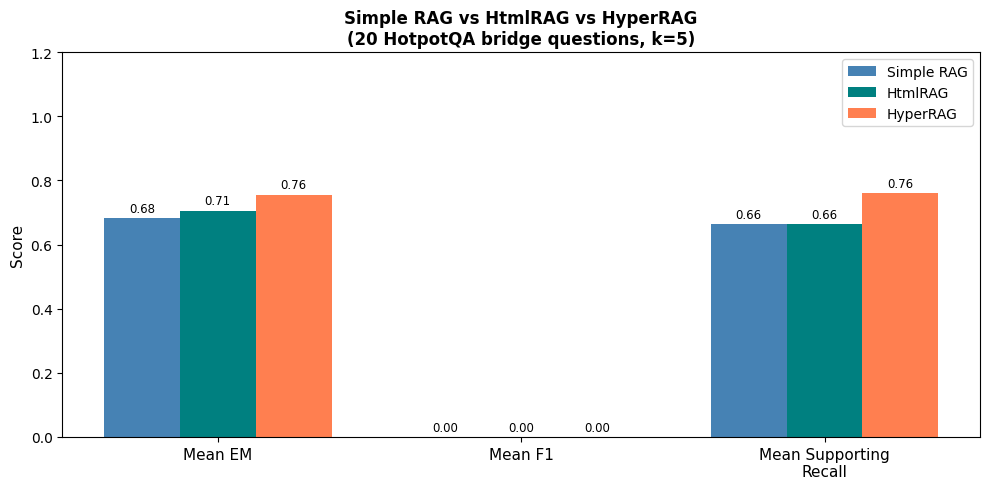

Saved: data/final_comparison.png


In [18]:
# ── Final Comparison Bar Chart ────────────────────────────────────────────────
metrics = ['Mean EM', 'Mean F1', 'Mean Supporting\nRecall']
values  = [
    [simple_data['mean_em'],  simple_data['mean_f1'],  simple_data['mean_sr']],
    [html_data['mean_em'],    html_data['mean_f1'],    html_data['mean_sr']],
    [mean_em_hyper,           mean_f1_hyper,           mean_spr_hyper],
]
colors  = ['steelblue', 'teal', 'coral']
labels  = ['Simple RAG', 'HtmlRAG', 'HyperRAG']

x = range(len(metrics))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for j, (vals, color, label) in enumerate(zip(values, colors, labels)):
    offset = (j - 1) * w
    bars = ax.bar([i + offset for i in x], vals, w, label=label, color=color)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(list(x))
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.2)
ax.set_title('Simple RAG vs HtmlRAG vs HyperRAG\n(20 HotpotQA bridge questions, k=5)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'final_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/final_comparison.png')


In [ ]:
# Per-question Supporting Recall: all three systems
ids         = [r['id'] for r in results_hyper]
simple_sr   = [r['supporting_recall'] for r in simple_data['per_question']]
html_sr     = [r['supporting_recall'] for r in html_data['per_question']]
hyper_sr    = [r['supporting_recall'] for r in results_hyper]

fig, ax = plt.subplots(figsize=(13, 4))
w = 0.25
bars1 = ax.bar([i - w for i in ids], simple_sr, w, label='Simple RAG', color='steelblue', alpha=0.85)
bars2 = ax.bar([i      for i in ids], html_sr,   w, label='HtmlRAG',    color='teal',      alpha=0.85)
bars3 = ax.bar([i + w  for i in ids], hyper_sr,  w, label='HyperRAG',   color='coral',     alpha=0.85)
ax.set_xlabel('Question ID')
ax.set_ylabel('Supporting Recall')
ax.set_title('Supporting Recall Per Question — 3 Systems')
ax.set_ylim(0, 1.25)
ax.legend()
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'per_question_sr.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: data/per_question_sr.png')


In [ ]:
# Which questions did HyperRAG improve over Simple RAG?
print('HyperRAG vs Simple RAG — Supporting Recall Per Question')
print(f'{"Q":<4} {"Simple":>8} {"HyperRAG":>10} {"Delta":>8}  {"Question"}')
print('-' * 90)
for sq, hq in zip(simple_data['per_question'], results_hyper):
    delta = hq['supporting_recall'] - sq['supporting_recall']
    sign  = '+' if delta > 0 else ('=' if delta == 0 else '-')
    print(f'{sq["id"]:<4} {sq["supporting_recall"]:>8.2f} {hq["supporting_recall"]:>10.2f} {sign}{abs(delta):>6.2f}  {sq["question"][:50]}')


HyperRAG vs Simple RAG — Supporting Recall Per Question
Q      Simple   HyperRAG    Delta  Question
------------------------------------------------------------------------------------------
0        1.00       1.00 =  0.00  The Oberoi family is part of a hotel company that 
1        1.00       1.00 =  0.00  Musician and satirist Allie Goertz wrote a song ab
2        1.00       1.00 =  0.00   What nationality was James Henry Miller's wife?
3        1.00       1.00 =  0.00  Cadmium Chloride is slightly soluble in this chemi
4        1.00       1.00 =  0.00  Which genus of moth in the world's seventh-largest
5        1.00       1.00 =  0.00  Who was once considered the best kick boxer in the
6        1.00       1.00 =  0.00  The Dutch-Belgian television series that "House of
7        1.00       1.00 =  0.00  What is the length of the track where the 2013 Liq
8        1.00       1.00 =  0.00  Fast Cars, Danger, Fire and Knives includes guest 
9        1.00       1.00 =  0.00  Gunmen from 

In [ ]:
with open(DATA_DIR / 'results_hyperrag.json', 'w') as f:
    json.dump({'mean_em': mean_em_hyper, 'mean_f1': mean_f1_hyper, 'mean_sr': mean_spr_hyper,
               'per_question': results_hyper}, f, indent=2)
print('Results saved → data/results_hyperrag.json')


Results saved → data/results_hyperrag.json


---
## Summary

| System | EM | F1 | Supporting Recall |
|--------|----|----|-------------------|
| Simple RAG | see above | see above | see above |
| HtmlRAG | see above | see above | see above |
| HyperRAG | see above | see above | see above |

**Key takeaway:**  
- **Supporting Recall** is the most meaningful metric for multi-hop retrieval. It tells you whether the system retrieved *both* pages needed to answer the question.
- HyperRAG should improve Supporting Recall by following hyperlinks to bridge pages that FAISS would not find on its own.
- If the corpus is very small (as in this V2), the graph may have few edges, limiting the expansion benefit.

**To see a bigger difference:** increase `N` from 20 to 100 in notebook 01, which will give more pages and a denser graph.
